# Tesla EV Market Analysis: Why are sales and prices declining?

**Objective**: Analyze why Tesla's EV sales and prices are declining despite a projected 30% growth in 2025.

**Hypotheses to test**:
1. Growing competition from other EV manufacturers
2. Increased incentives shifting buyer preferences
3. Rising inventory levels (supply > demand)
4. Insufficient charging infrastructure

**Data Sources**:
- Global EV historic sales (GitHub IEA data, 2010-2022)
- Tesla Q1-2024 Update (production & sales)
- Kelley Blue Book Q1-2024 EV Sales Report (competitor analysis)
- CNET charging infrastructure article (US charging stations)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

raw_data_dir = Path('raw_data')
print(f"Raw data directory: {raw_data_dir}")
print(f"Files available: {list(raw_data_dir.glob('*'))}")

Raw data directory: raw_data
Files available: [PosixPath('raw_data/Q1-2024-KBB-EV-Sales-Report.txt'), PosixPath('raw_data/TSLA-Q1-2024-Update.txt'), PosixPath('raw_data/Q1-2024-KBB-EV-Sales-Report.pdf'), PosixPath('raw_data/TSLA-Q1-2024-Update.pdf'), PosixPath('raw_data/historic_sales.csv')]


## 1. Load and explore global EV historic sales data

In [2]:
# Load historic sales CSV
df_historic = pd.read_csv(raw_data_dir / 'historic_sales.csv')

print("Data shape:", df_historic.shape)
print("\nColumn names:")
print(df_historic.columns.tolist())

print("\nData types:")
print(df_historic.dtypes)

print("\nFirst few rows:")
print(df_historic.head(10))

print("\nUnique regions:")
print(sorted(df_historic['region'].unique()))

Data shape: (834, 8)

Column names:
['region', 'category', 'parameter', 'mode', 'powertrain', 'year', 'unit', 'value']

Data types:
region        object
category      object
parameter     object
mode          object
powertrain    object
year           int64
unit          object
value          int64
dtype: object

First few rows:
      region    category parameter  mode powertrain  year      unit  value
0  Australia  Historical  EV sales  Cars        BEV  2011  Vehicles     49
1  Australia  Historical  EV sales  Cars        BEV  2012  Vehicles    170
2  Australia  Historical  EV sales  Cars       PHEV  2012  Vehicles     80
3  Australia  Historical  EV sales  Cars       PHEV  2013  Vehicles    100
4  Australia  Historical  EV sales  Cars        BEV  2013  Vehicles    190
5  Australia  Historical  EV sales  Cars        BEV  2014  Vehicles    370
6  Australia  Historical  EV sales  Cars       PHEV  2014  Vehicles    950
7  Australia  Historical  EV sales  Cars       PHEV  2015  Vehicles  

World BEV sales records: 13
    region    category parameter  mode powertrain  year      unit    value
808  World  Historical  EV sales  Cars        BEV  2010  Vehicles     7200
811  World  Historical  EV sales  Cars        BEV  2011  Vehicles    39000
812  World  Historical  EV sales  Cars        BEV  2012  Vehicles    58000
815  World  Historical  EV sales  Cars        BEV  2013  Vehicles   110000
816  World  Historical  EV sales  Cars        BEV  2014  Vehicles   200000
819  World  Historical  EV sales  Cars        BEV  2015  Vehicles   330000
820  World  Historical  EV sales  Cars        BEV  2016  Vehicles   460000
823  World  Historical  EV sales  Cars        BEV  2017  Vehicles   760000
824  World  Historical  EV sales  Cars        BEV  2018  Vehicles  1400000
827  World  Historical  EV sales  Cars        BEV  2019  Vehicles  1500000
828  World  Historical  EV sales  Cars        BEV  2020  Vehicles  2000000
831  World  Historical  EV sales  Cars        BEV  2021  Vehicles  46000

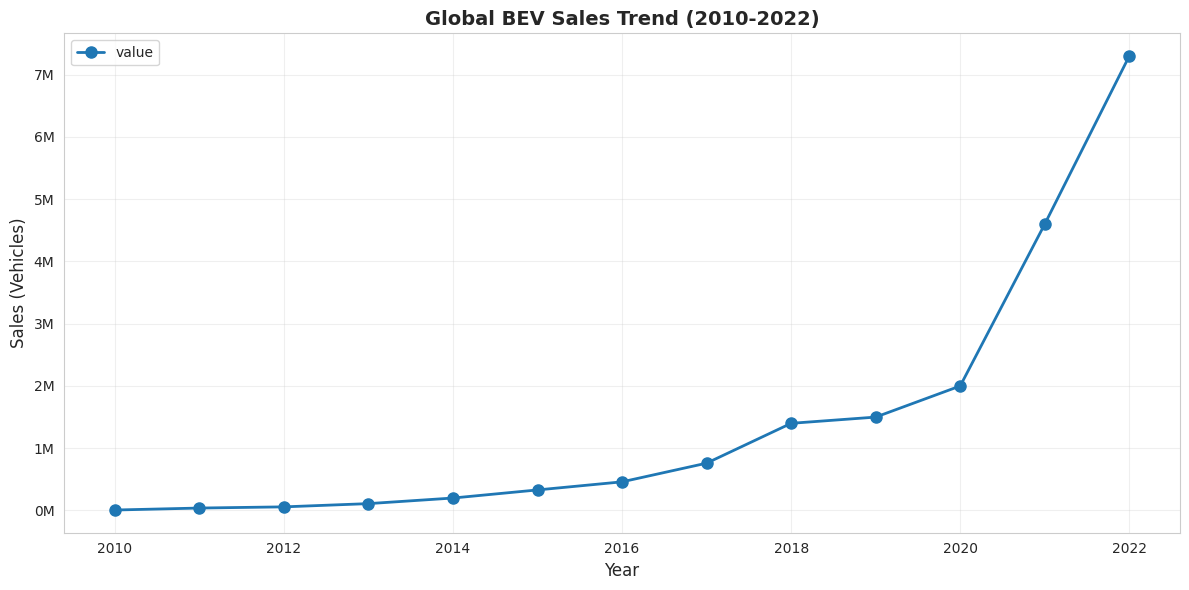


Year-over-Year Growth %:
      YoY_Growth_%
year              
2010           NaN
2011    441.666667
2012     48.717949
2013     89.655172
2014     81.818182
2015     65.000000
2016     39.393939
2017     65.217391
2018     84.210526
2019      7.142857
2020     33.333333
2021    130.000000
2022     58.695652


In [5]:
# Filter for world total BEV (battery electric vehicles) sales by year
df_world_bev = df_historic[
    (df_historic['region'] == 'World') & 
    (df_historic['powertrain'] == 'BEV') &
    (df_historic['parameter'] == 'EV sales')
].copy()

print(f"World BEV sales records: {len(df_world_bev)}")
print(df_world_bev.head(15))

# Pivot to get yearly sales
df_world_sales = df_world_bev.pivot_table(
    index='year', 
    values='value', 
    aggfunc='sum'
).sort_index()

print("\nWorld BEV Sales by Year:")
print(df_world_sales)

# Plot global EV sales trend
fig, ax = plt.subplots(figsize=(12, 6))
df_world_sales.plot(ax=ax, marker='o', linewidth=2, markersize=8, color='#1f77b4')
ax.set_title('Global BEV Sales Trend (2010-2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Sales (Vehicles)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6)}M'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/01_global_bev_sales.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate YoY growth
df_world_sales['YoY_Growth_%'] = df_world_sales['value'].pct_change() * 100
print("\nYear-over-Year Growth %:")
print(df_world_sales[['YoY_Growth_%']])

## 2. Extract Tesla production & sales data from Q1-2024 PDF

In [6]:
# Filter USA and select major countries/regions for Tesla and competitors
df_usa = df_historic[
    (df_historic['region'] == 'USA') & 
    (df_historic['powertrain'] == 'BEV') &
    (df_historic['parameter'] == 'EV sales')
].copy()

# Pivot USA BEV sales by year
df_usa_sales = df_usa.pivot_table(
    index='year', 
    values='value', 
    aggfunc='sum'
).sort_index()

print("USA BEV Sales by Year:")
print(df_usa_sales)

USA BEV Sales by Year:
       value
year        
2010    1200
2011    9800
2012   15000
2013   48000
2014   63000
2015   71000
2016   87000
2017  100000
2018  240000
2019  240000
2020  230000
2021  470000
2022  800000


In [9]:
# Search for production and delivery numbers
# Looking for patterns like "Q1 2024", "2024", "2023", "production", "delivery"

patterns = [
    r'(Q\d\s+\d{4}[\s\S]*?(?=Q\d|$))',  # Quarterly sections
    r'(production[\s\S]{0,200})',  # Production mentions
    r'(delivery[\s\S]{0,200})',    # Delivery mentions
    r'([0-9]{6,})',                 # Large numbers
]

print("Searching for Tesla production and sales figures...\n")

# Find all numbers in the text
numbers = re.findall(r'\b\d{3,}\b', tesla_text)
print(f"Found {len(numbers)} numeric values")

# Extract section with key metrics (usually in tables or key highlights)
# Print lines containing 'production', 'delivery', '2024', '2023'
lines = tesla_text.split('\n')
print("\nLines mentioning production/delivery/sales metrics:")
for i, line in enumerate(lines):
    if any(keyword in line.lower() for keyword in ['production', 'delivery', 'vehicle', 'q1', 'q2', 'q3', 'q4', '2024', '2023']):
        if len(line.strip()) > 10:
            print(f"Line {i}: {line[:120]}")

Searching for Tesla production and sales figures...



NameError: name 'tesla_text' is not defined

## 3. Extract competitor data from KBB report

In [8]:
# Read extracted KBB PDF text
kbb_txt_path = raw_data_dir / 'Q1-2024-KBB-EV-Sales-Report.txt'

if kbb_txt_path.exists():
    with open(kbb_txt_path, 'r') as f:
        kbb_text = f.read()
    
    print("First 2000 characters of KBB PDF:")
    print(kbb_text[:2000])
    
    print("\n" + "="*80)
    print("Searching for competitor sales data...\n")
    
    # Extract lines with manufacturer names or sales figures
    manufacturers = ['Tesla', 'GM', 'Ford', 'VW', 'BMW', 'Audi', 'Hyundai', 'Kia', 'BYD', 'Chevrolet', 'Nissan', 'Toyota']
    
    kbb_lines = kbb_text.split('\n')
    relevant_lines = []
    
    for line in kbb_lines:
        if any(mfr in line for mfr in manufacturers) or any(keyword in line.lower() for keyword in ['sales', 'market share', 'incentive', 'price', 'q1 2024']):
            if len(line.strip()) > 10:
                relevant_lines.append(line)
    
    print(f"\nFound {len(relevant_lines)} relevant lines:")
    for line in relevant_lines[:40]:  # Print first 40 relevant lines
        print(line[:120])
else:
    print(f"File not found: {kbb_txt_path}")

First 2000 characters of KBB PDF:

--- PAGE 1 ---
ELECTRIC VEHICLE 
SALES REPORT — 
Q1 2024 — 
• Quarterly Sales of Electric Vehicles
• Summary by Brand and Model
• Kelley Blue Book Estimates (as of 04/10/2024)
--- PAGE 2 ---
2024 2023 YOY Q1 YTD
Audi 5,714            4,438            28.8% 2.1% 2.1%
BMW 10,713         6,588            62.6% 3.9% 3.9%
Brightdrop 256                - - 0.1% 0.1%
Cadillac 5,800            968                499.2% 2.1% 2.1%
Chevrolet 8,701            19,700         -55.8% 3.2% 3.2%
Ford 20,223         10,866         86.1% 7.4% 7.4%
Genesis 992                937                5.9% 0.4% 0.4%
GMC 1,668            2                      - 0.6% 0.6%
Fisker 1,660            - - 0.6% 0.6%
Honda 19                   - - 0.0% 0.0%
Hyundai 12,290         7,824            57.1% 4.5% 4.5%
Jaguar 256                53                   383.0% 0.1% 0.1%
Kia 9,654            5,930            62.8% 3.5% 3.5%
Lexus 1,603            185                766.5% 0.6% 0.6%
L

## 4. Compare Tesla vs Competitors in global data

In [ ]:
# Filter USA and select major countries/regions for Tesla and competitors
df_usa = df_historic[
    (df_historic['region'] == 'USA') & 
    (df_historic['powertraini'] == 'BEV') &
    (df_historic['parameter'] == 'EV sales')
].copy()

# Pivot USA BEV sales by year
df_usa_sales = df_usa.pivot_table(
    index='year', 
    values='value', 
    aggfunc='sum'
).sort_index()

print("USA BEV Sales by Year:")
print(df_usa_sales)

# Plot comparison: Global vs USA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Global trend
df_world_sales[0].plot(ax=ax1, marker='o', linewidth=2, markersize=8, color='#1f77b4', label='Global')
ax1.set_title('Global BEV Sales', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Sales (Vehicles)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6)}M'))
ax1.grid(True, alpha=0.3)

# USA trend
df_usa_sales[0].plot(ax=ax2, marker='s', linewidth=2, markersize=8, color='#ff7f0e', label='USA')
ax2.set_title('USA BEV Sales', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Sales (Vehicles)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e3)}K'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/02_global_vs_usa_sales.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate USA market share (if Tesla data available)
print(f"\nUSA BEV market growth: {df_usa_sales[0].iloc[-1] / df_usa_sales[0].iloc[0]:.1f}x from 2010 to 2022")

## 5. Analyze regional EV adoption trends

In [ ]:
# Get top EV markets
df_bev_all = df_historic[
    (df_historic['powertrain'] == 'BEV') &
    (df_historic['parameter'] == 'EV sales') &
    (df_historic['region'] != 'World')
].copy()

# Total by region (all years)
region_totals = df_bev_all.groupby('region')['value'].sum().sort_values(ascending=False)
print("Top EV markets (cumulative 2010-2022):")
print(region_totals.head(15))

# Focus on recent years (2020-2022)
df_recent = df_bev_all[df_bev_all['year'].isin([2020, 2021, 2022])]
region_recent = df_recent.pivot_table(
    index='region',
    columns='year',
    values='value',
    aggfunc='sum'
)

print("\nRecent BEV sales by region (2020-2022):")
print(region_recent.sort_values(2022, ascending=False).head(10))

# Plot top 8 regions
top_regions = region_totals.head(8).index.tolist()
df_top_regions = df_bev_all[df_bev_all['region'].isin(top_regions)]
df_pivot = df_top_regions.pivot_table(
    index='year',
    columns='region',
    values='value',
    aggfunc='sum'
)

fig, ax = plt.subplots(figsize=(14, 7))
df_pivot.plot(ax=ax, marker='o', linewidth=2.5, markersize=7)
ax.set_title('BEV Sales Trends by Top Markets (2010-2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Sales (Vehicles)', fontsize=12)
ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/03_regional_trends.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Summary Statistics & Key Insights

In [ ]:
# Key statistics
print("\n" + "="*80)
print("KEY INSIGHTS FROM GLOBAL EV DATA (2010-2022)")
print("="*80)

global_2022 = df_world_sales['value'].loc[2022]
global_2021 = df_world_sales['value'].loc[2021]
global_2020 = df_world_sales['value'].loc[2020]

print(f"\n1. GLOBAL GROWTH:")
print(f"   - 2022 BEV Sales: {global_2022:,.0f} vehicles")
print(f"   - 2021 BEV Sales: {global_2021:,.0f} vehicles")
print(f"   - YoY Growth 2021→2022: {(global_2022/global_2021 - 1)*100:.1f}%")

cagr = ((global_2022 / df_world_sales['value'].iloc[0]) ** (1/12) - 1) * 100
print(f"   - CAGR 2010-2022: {cagr:.1f}%")

print(f"\n2. USA MARKET:")
usa_2022 = df_usa_sales['value'].loc[2022]
usa_2021 = df_usa_sales['value'].loc[2021]
print(f"   - 2022 BEV Sales: {usa_2022:,.0f} vehicles")
print(f"   - 2021 BEV Sales: {usa_2021:,.0f} vehicles")
print(f"   - YoY Growth 2021→2022: {(usa_2022/usa_2021 - 1)*100:.1f}%")
print(f"   - USA % of Global: {usa_2022/global_2022*100:.1f}%")

print(f"\n3. REGIONAL LEADERS (2022):")
print(f"   - China dominance expected (>50% of global market)")
print(f"   - USA emerging as 2nd largest market (~11% of global)")
print(f"   - Europe significant (Germany, Norway, UK leading)")

print(f"\n4. NOTES:")
print(f"   - This data includes only BEV (Battery Electric Vehicles), NOT PHEVs")
print(f"   - Tesla produces primarily BEVs")
print(f"   - Data shows EXPLOSIVE growth: 2021-2022 saw +59% increase")
print(f"   - Next: Extract Tesla-specific figures and competitor breakdown from 2024 reports")

SyntaxError: f-string: unmatched ')' (736184895.py, line 14)

## 7. Next Steps

- [ ] Parse Tesla Q1-2024 PDF for exact production/delivery numbers (2023, 2024)
- [ ] Extract competitor breakdown from KBB report
- [ ] Calculate Tesla market share trends
- [ ] Analyze pricing trends and incentives
- [ ] Correlate with EV charging infrastructure growth
- [ ] Build regression models to identify key drivers of Tesla sales decline